Need:
Introduction
Loading the Datasets
Data Cleaning and Preparation
Data Aggregation and Grouping
Data Visualization with Matplotlib
Conclusion

Introduction:
This project aims to analyze the relationship between academic performance and mental 
health among students. Specifically, we will utilize the real-world dataset, Student Mental Health and Burnout (Kaggle, 2026).The dataset includes variables related to mental health conditions and 
overall academic performance, such as stress levels, sleep hours, depression levels, and study 
hours. Student demographics are also included in the data set, with a million entries. By cleaning and 
analyzing the datasets, we seek to determine whether a statistically meaningful correlation 
exists between academic outcomes and mental health factors.

In [38]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
# Load the student mental health burnout 1M Report dataset which can be downloaded at https://www.kaggle.com/datasets/sharmajicoder/student-mental-health-and-burnout
df = pd.read_csv('student_mental_health_burnout_1M.csv')


In [39]:
#Data Cleaning:
#preview datasets
print(df.head())
print(df.info())
print(df.shape)
print(df.columns)

   age gender  academic_year  study_hours_per_day  exam_pressure  \
0   23   Male              2             5.596071       6.487218   
1   20   Male              3             5.597171       5.631481   
2   29   Male              2             2.580491       6.015297   
3   27   Male              4             4.607208       6.684005   
4   24   Male              4             2.186569       4.010945   

   academic_performance  stress_level  anxiety_score  depression_score  \
0             68.411114      4.116950       2.275713          1.986730   
1             67.682159      0.349489       0.000000          0.000000   
2             58.372363      3.476177       2.425201          0.851996   
3             68.925653      6.778843       4.512425          4.285645   
4             69.141915      1.854595       1.102558          0.000000   

   sleep_hours  physical_activity  social_support  screen_time  \
0     6.880545           2.728861        6.470080     4.993801   
1     7.463339

In [40]:
#Data Cleaning:
# Remove duplicate rows
df = df.drop_duplicates()

# Check missing values
print(df.isnull().sum())

# Drop rows with missing values, if any
df = df.dropna()

# Standardize column names
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

# Check cleaned data
print(df.head())
print(df.shape)
print(f"Data points remaining after cleaning: {len(df)}")

age                     0
gender                  0
academic_year           0
study_hours_per_day     0
exam_pressure           0
academic_performance    0
stress_level            0
anxiety_score           0
depression_score        0
sleep_hours             0
physical_activity       0
social_support          0
screen_time             0
internet_usage          0
financial_stress        0
family_expectation      0
burnout_score           0
mental_health_index     0
risk_level              0
dropout_risk            0
dtype: int64
   age gender  academic_year  study_hours_per_day  exam_pressure  \
0   23   Male              2             5.596071       6.487218   
1   20   Male              3             5.597171       5.631481   
2   29   Male              2             2.580491       6.015297   
3   27   Male              4             4.607208       6.684005   
4   24   Male              4             2.186569       4.010945   

   academic_performance  stress_level  anxiety_score  depr

In [41]:
print(df.describe())


                  age   academic_year  study_hours_per_day   exam_pressure  \
count  1000000.000000  1000000.000000       1000000.000000  1000000.000000   
mean        22.996456        2.500782             5.001727        5.998810   
std          3.742579        1.117749             1.989340        1.548268   
min         17.000000        1.000000             0.000000        1.000000   
25%         20.000000        2.000000             3.650644        4.944647   
50%         23.000000        3.000000             4.998222        5.998906   
75%         26.000000        4.000000             6.345532        7.051914   
max         29.000000        4.000000            14.000000       10.000000   

       academic_performance    stress_level   anxiety_score  depression_score  \
count        1000000.000000  1000000.000000  1000000.000000    1000000.000000   
mean              70.999135        4.246462        2.986413          1.274728   
std                5.660073        1.678998        1.5

In [42]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix["academic_performance"].sort_values(ascending=False))

academic_performance    1.000000
study_hours_per_day     0.388611
exam_pressure           0.126926
stress_level            0.059694
burnout_score           0.057089
anxiety_score           0.045428
depression_score        0.035889
dropout_risk            0.032104
age                     0.000720
academic_year           0.000567
social_support          0.000202
financial_stress       -0.000148
family_expectation     -0.000577
physical_activity      -0.000841
screen_time            -0.001054
internet_usage         -0.001149
sleep_hours            -0.001585
mental_health_index    -0.056318
Name: academic_performance, dtype: float64


The analysis shows that academic performance is most strongly associated with study habits rather than mental health factors. Study hours per day had a moderate positive correlation (r = 0.389), making it the most influential variable. In contrast, mental health indicators such as stress, anxiety, depression, and burnout showed only very weak relationships with academic performance (r < 0.06).These findings suggest that while mental health may play a role, its direct impact on academic outcomes in this dataset is minimal compared to behavioral factors like studying.

In [48]:
print(corr_matrix["dropout_risk"].sort_values(ascending=False))

dropout_risk            1.000000
burnout_score           0.689748
depression_score        0.654336
stress_level            0.554140
anxiety_score           0.461764
financial_stress        0.406470
exam_pressure           0.243437
study_hours_per_day     0.187382
family_expectation      0.138195
academic_performance    0.032104
screen_time            -0.000959
internet_usage         -0.001100
academic_year          -0.001220
age                    -0.001895
physical_activity      -0.070918
sleep_hours            -0.191171
social_support         -0.394994
mental_health_index    -0.626425
Name: dropout_risk, dtype: float64


Academic performance and dropout risk are influenced by different factors. While grades are primarily driven by study behavior, dropout risk is strongly associated with mental health conditions such as burnout, depression, and stress.The analysis reveals that dropout risk is strongly associated with mental health variables rather than academic performance. Burnout score (r = 0.690), depression score (r = 0.654), and stress level (r = 0.554) show the strongest positive correlations with dropout risk, indicating that students experiencing psychological distress are significantly more likely to leave their academic programs. Conversely, protective factors such as mental health index (r = -0.626) and social support (r = -0.395) are strongly associated with reduced dropout risk. Notably, academic performance shows almost no correlation with dropout risk (r = 0.032), suggesting that students do not drop out due to poor grades, but rather due to mental health challenges.While academic success is primarily influenced by study behavior, dropout risk is driven by mental health and emotional well-being. This suggests that improving student retention requires psychological and social support interventions rather than purely academic solutions.

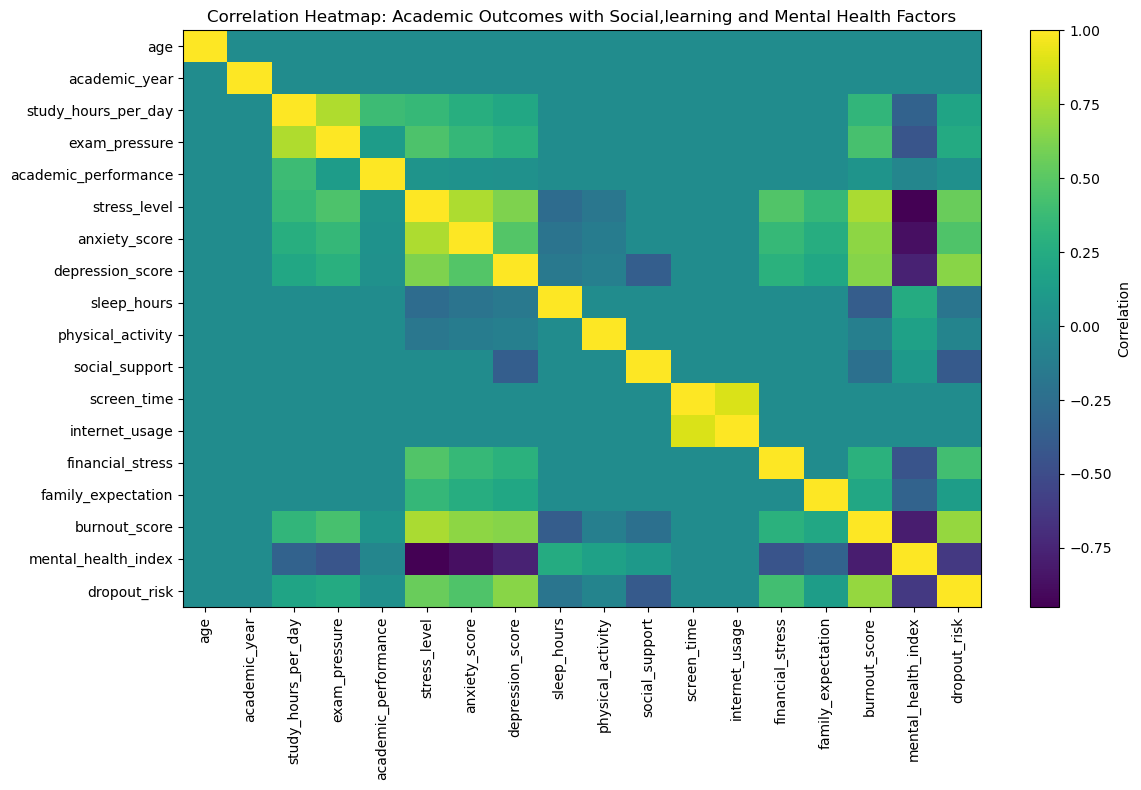

In [52]:

plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap: Academic Outcomes with Social,learning and Mental Health Factors")
plt.tight_layout()
plt.show()

In [54]:
#social factors and academics aalysis:
analysis_cols_social_factors_and_academics = [
    "academic_performance",
    "social_support",
    "financial_stress",
    "family_expectation",
    "dropout_risk"
]

df_analysis2 = df[analysis_cols_social_factors_and_academics]

df_analysis2.head()

,academic_performance,social_support,financial_stress,family_expectation,dropout_risk
0,68.411114,6.470080,3.446626,3.586147,1.746601
1,67.682159,0.000000,2.814039,5.478666,0.000000
2,58.372363,6.901725,4.918515,6.068155,0.696941
3,68.925653,2.349857,6.915885,6.557540,5.380592
4,69.141915,4.512921,4.382820,5.934779,0.000000


In [56]:
corr_matrix2 = df_analysis2.corr(numeric_only=True)
print(corr_matrix2["academic_performance"].sort_values(ascending=False))
print(corr_matrix2["dropout_risk"].sort_values(ascending=False))

academic_performance    1.000000
dropout_risk            0.032104
social_support          0.000202
financial_stress       -0.000148
family_expectation     -0.000577
Name: academic_performance, dtype: float64
dropout_risk            1.000000
financial_stress        0.406470
family_expectation      0.138195
academic_performance    0.032104
social_support         -0.394994
Name: dropout_risk, dtype: float64


Students can still perform well academically even when facing stress, financial pressure, or lack of support. The results of this analysis indicate that academic performance has virtually no relationship with social or environmental stressors such as financial stress, family expectations, and social support. All correlations were near zero, suggesting that these factors do not directly influence grades. Additionally, dropout risk shows no meaningful association with academic performance (r = 0.032), reinforcing the idea that students may maintain academic success while still being at risk of leaving their studies. This highlights a critical disconnect between academic outcomes and student well-being.In contrast, dropout risk is moderately associated with financial stress (r = 0.406) and negatively associated with social support (r = -0.395), suggesting that students experiencing financial pressure and lacking support systems are more likely to leave their academic programs. Notably, academic performance has almost no relationship with dropout risk (r = 0.032), highlighting a disconnect between academic success and student retention.

In [59]:
#mental health factors and academics aalysis:
analysis_cols_mentalhealth_factors_and_academics = [
     "academic_performance",
    "stress_level",
    "sleep_hours",
    "depression_score",
    "anxiety_score",
    "burnout_score",
    "mental_health_index",
    "screen_time",
    "physical_activity",
    "dropout_risk"
]

df_analysis3 = df[analysis_cols_mentalhealth_factors_and_academics]

df_analysis3.head()

,academic_performance,stress_level,sleep_hours,depression_score,anxiety_score,burnout_score,mental_health_index,screen_time,physical_activity,dropout_risk
0,68.411114,4.116950,6.880545,1.986730,2.275713,2.037344,7.074487,4.993801,2.728861,1.746601
1,67.682159,0.349489,7.463339,0.000000,0.000000,0.000000,9.860204,3.862980,3.690866,0.000000
2,58.372363,3.476177,8.946670,0.851996,2.425201,0.000000,7.626370,5.428880,3.296720,0.696941
3,68.925653,6.778843,4.571380,4.285645,4.512425,7.227651,4.649042,6.304842,2.065480,5.380592
4,69.141915,1.854595,5.989324,0.000000,1.102558,0.000000,8.927394,4.903146,4.026504,0.000000


In [61]:
corr_matrix3= df_analysis3.corr(numeric_only=True)
print(corr_matrix3["academic_performance"].sort_values(ascending=False))
print(corr_matrix3["dropout_risk"].sort_values(ascending=False))

academic_performance    1.000000
stress_level            0.059694
burnout_score           0.057089
anxiety_score           0.045428
depression_score        0.035889
dropout_risk            0.032104
physical_activity      -0.000841
screen_time            -0.001054
sleep_hours            -0.001585
mental_health_index    -0.056318
Name: academic_performance, dtype: float64
dropout_risk            1.000000
burnout_score           0.689748
depression_score        0.654336
stress_level            0.554140
anxiety_score           0.461764
academic_performance    0.032104
screen_time            -0.000959
physical_activity      -0.070918
sleep_hours            -0.191171
mental_health_index    -0.626425
Name: dropout_risk, dtype: float64


Academic performance is not a reliable indicator of student well-being. While students may maintain acceptable grades, underlying mental health challenges significantly increase their likelihood of dropping out. Therefore, interventions aimed at improving student retention should focus on mental health support rather than solely academic performance.

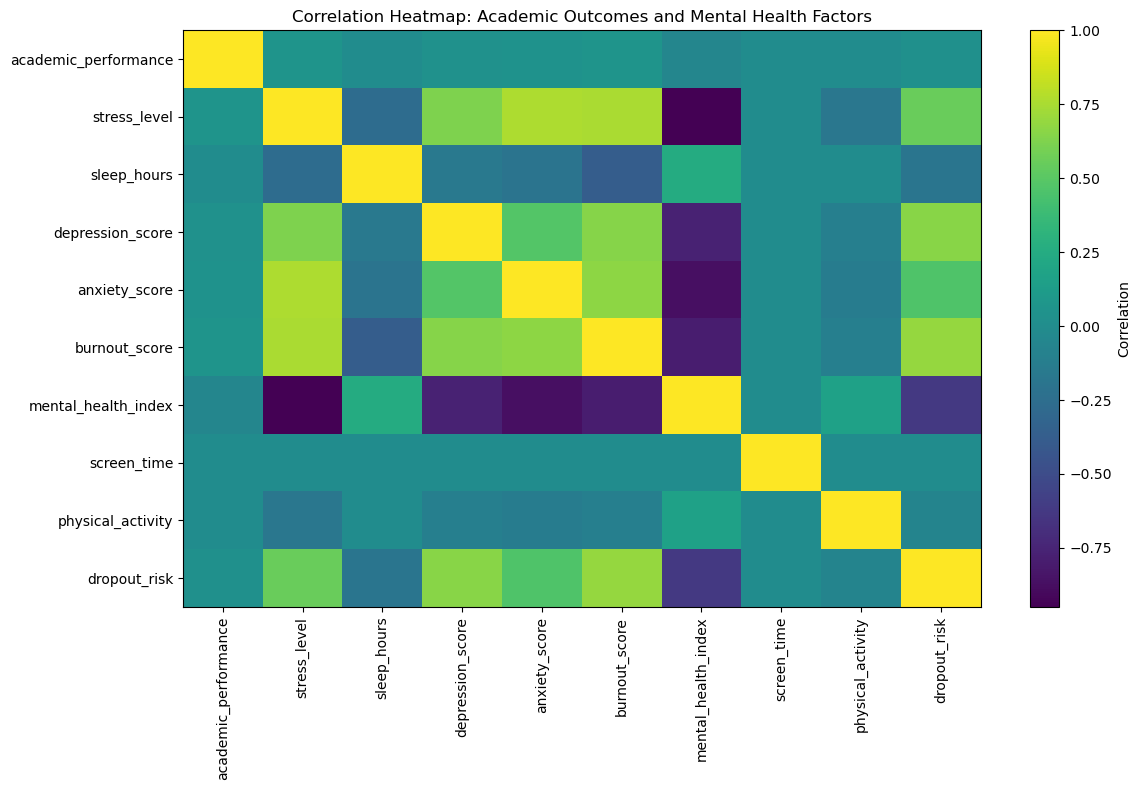

In [64]:
plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix3, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix3.columns)), corr_matrix3.columns, rotation=90)
plt.yticks(range(len(corr_matrix3.columns)), corr_matrix3.columns)
plt.title("Correlation Heatmap: Academic Outcomes and Mental Health Factors")
plt.tight_layout()
plt.show()

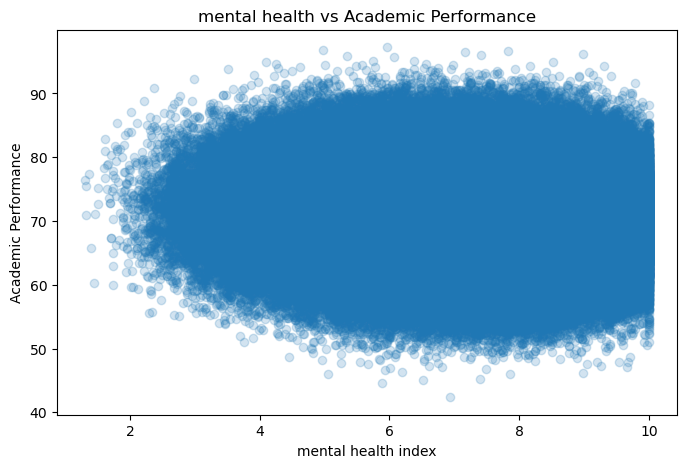

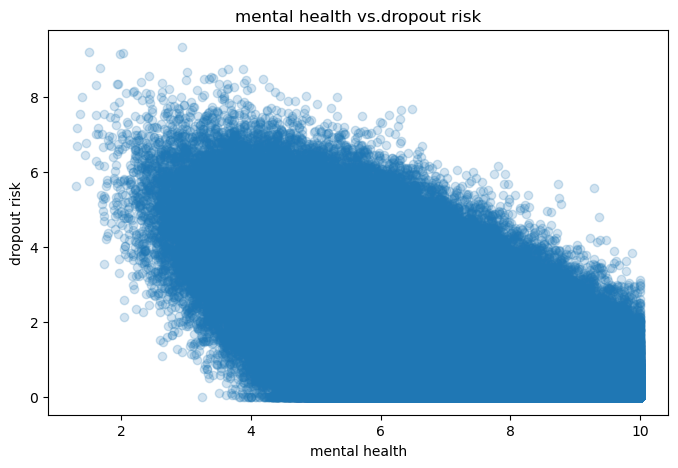

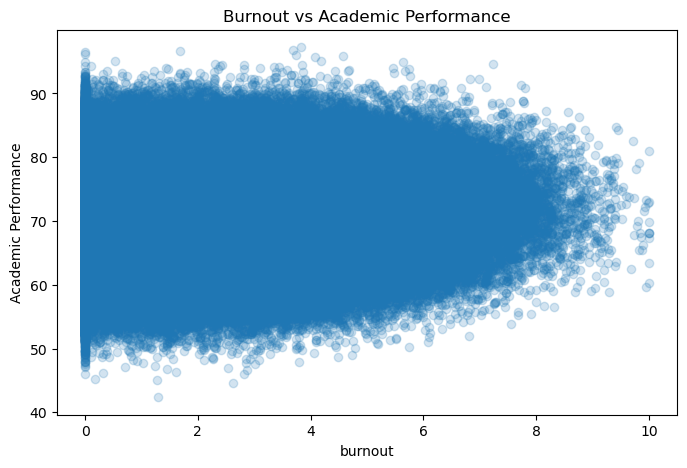

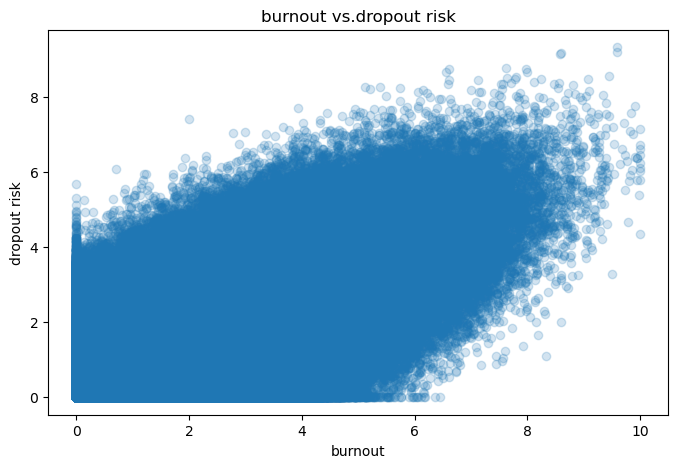

In [66]:
plt.figure(figsize=(8, 5))
plt.scatter(df["mental_health_index"], df["academic_performance"], alpha=0.2)
plt.xlabel("mental health index")
plt.ylabel("Academic Performance")
plt.title("mental health vs Academic Performance")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["mental_health_index"], df["dropout_risk"], alpha=0.2)
plt.xlabel("mental health")
plt.ylabel("dropout risk")
plt.title("mental health vs.dropout risk")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["burnout_score"], df["academic_performance"], alpha=0.2)
plt.xlabel("burnout")
plt.ylabel("Academic Performance")
plt.title("Burnout vs Academic Performance")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["burnout_score"], df["dropout_risk"], alpha=0.2)
plt.xlabel("burnout")
plt.ylabel("dropout risk")
plt.title("burnout vs.dropout risk")
plt.show()


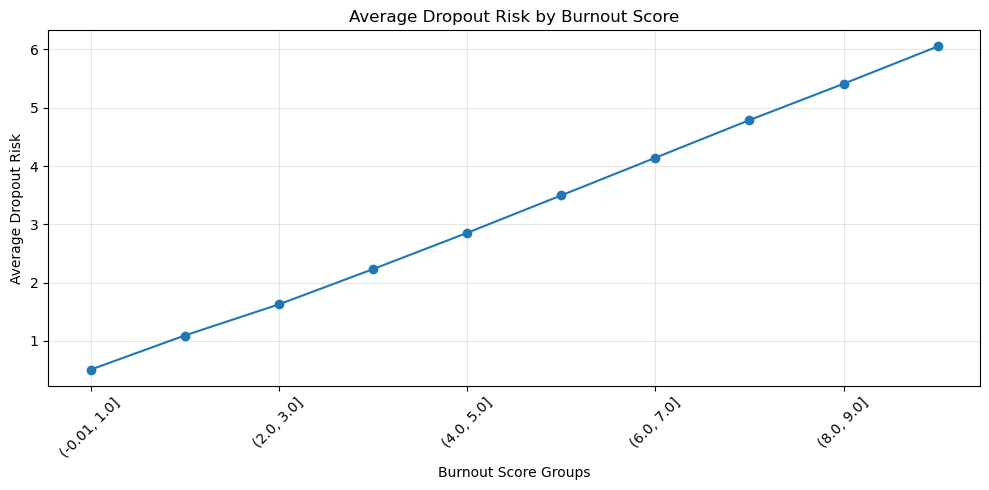

In [67]:
df["burnout_group"] = pd.cut(df["burnout_score"], bins=10)

burnout_dropout = df.groupby("burnout_group", observed=True)["dropout_risk"].mean()

plt.figure(figsize=(10, 5))
burnout_dropout.plot(marker="o")

plt.xlabel("Burnout Score Groups")
plt.ylabel("Average Dropout Risk")
plt.title("Average Dropout Risk by Burnout Score")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

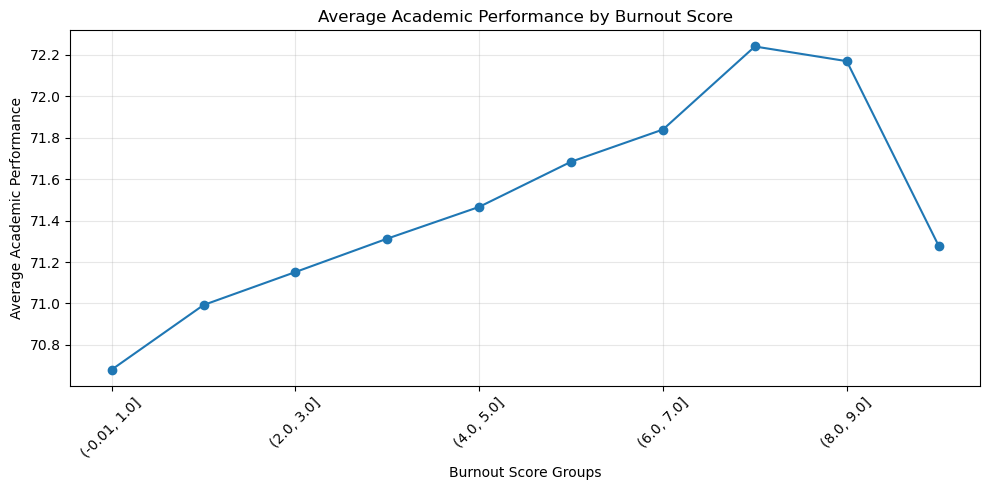

In [68]:
burnout_performance = df.groupby("burnout_group", observed=True)["academic_performance"].mean()

plt.figure(figsize=(10, 5))
burnout_performance.plot(marker="o")

plt.xlabel("Burnout Score Groups")
plt.ylabel("Average Academic Performance")
plt.title("Average Academic Performance by Burnout Score")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [69]:
# Compare performance across high vs low financial stress
df["high_financial_stress"] = df["financial_stress"] > df["financial_stress"].median()

df.groupby("high_financial_stress")["academic_performance"].mean()

high_financial_stress
False    71.000696
True     70.997573
Name: academic_performance, dtype: float64

In [70]:
# Compare dropout risk across social support levels
df["low_support"] = df["social_support"] < df["social_support"].median()

df.groupby("low_support")["dropout_risk"].mean()

low_support
False    0.895554
True     1.754237
Name: dropout_risk, dtype: float64

The analysis demonstrates that social support plays a critical role in student retention. Students with low levels of social support exhibit nearly double the dropout risk compared to those with higher support levels. Despite this, social support shows virtually no relationship with academic performance, indicating that students may maintain grades while still being at risk of leaving due to a lack of emotional or social resources. These findings highlight the importance of support systems in promoting student persistence.

In [73]:
#compare dropout risk by gender
gender_summary1= df.groupby("gender")["dropout_risk"].agg(
    ["count", "mean", "median", "std"]
)
gender_summary1

,count,mean,median,std
gender,,,,
Female,480070,1.325010,1.008219,1.344079
Male,479643,1.325233,1.011084,1.342028
Other,40287,1.319509,1.010126,1.334925


There is no meaningful difference in dropout risk across gender groups.

In [80]:
gender_summary2 = df.groupby("gender")["academic_performance"].agg(
    ["count", "mean", "median", "std"]
)
gender_summary2

,count,mean,median,std
gender,,,,
Female,480070,70.997760,70.995731,5.662366
Male,479643,71.000305,71.005280,5.657556
Other,40287,71.001579,70.968734,5.662833


There is no meaningful difference in academic performance across gender groups.

Exploratory Data Analysis

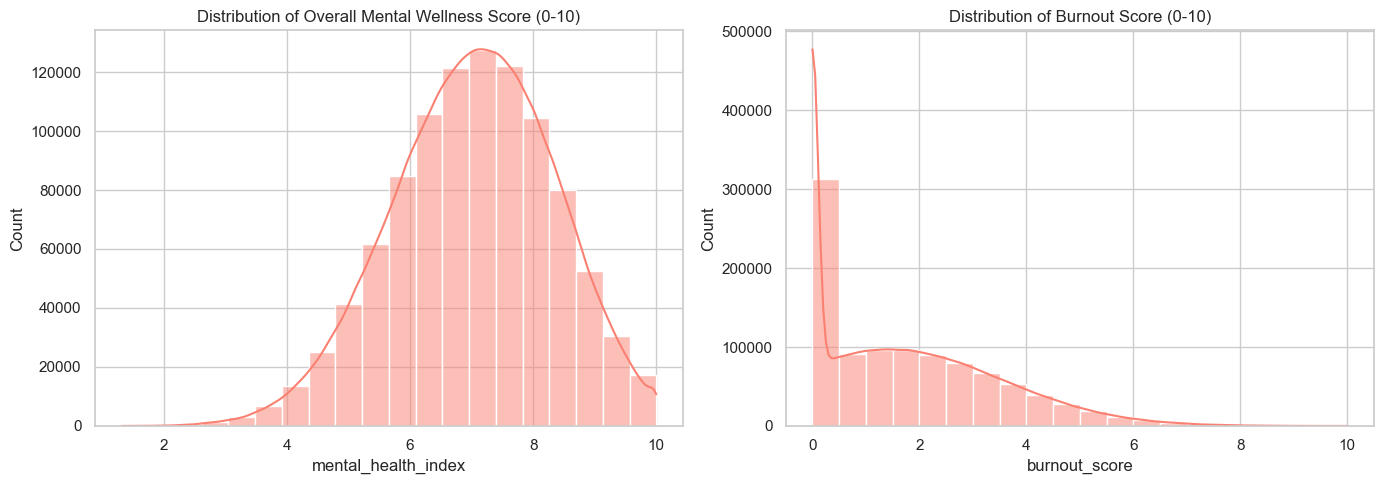

In [133]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['mental_health_index'], bins=20, kde=True, color='salmon', ax=axes[0])
axes[0].set_title('Distribution of Overall Mental Wellness Score (0-10)')
axes[0].ticklabel_format(style='plain') # Prevents scientific notation

sns.histplot(df['burnout_score'], bins=20, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribution of Burnout Score (0-10)')
axes[1].ticklabel_format(style='plain') # Prevents scientific notation

plt.tight_layout()
plt.show()

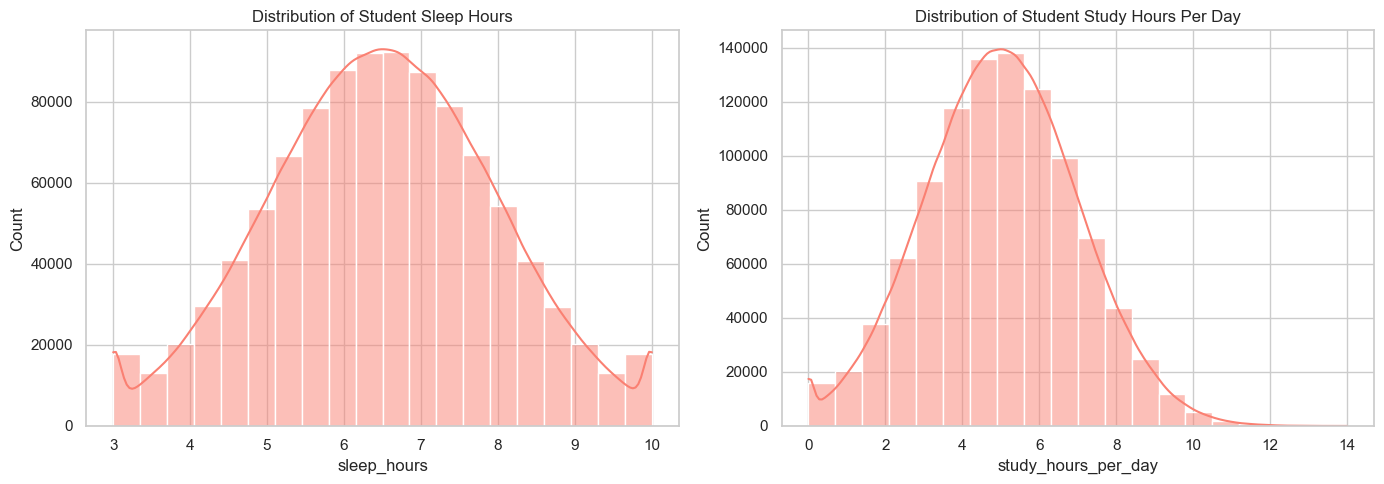

In [137]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['sleep_hours'], bins=20, kde=True, color='salmon', ax=axes[0])
axes[0].set_title('Distribution of Student Sleep Hours')
axes[0].ticklabel_format(style='plain') # Prevents scientific notation

sns.histplot(df['study_hours_per_day'], bins=20, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribution of Student Study Hours Per Day')
axes[1].ticklabel_format(style='plain') # Prevents scientific notation

plt.tight_layout()
plt.show()

Binarizing Data for Logistic Regression + Some Deeper Explorartory Analysis Using New Binarized Data

In [109]:
mean_dropout_risk = df['dropout_risk'].mean()
std_dropout_risk = df['dropout_risk'].std()
df['dropout_risk_zscore'] = (df['dropout_risk'] - mean_dropout_risk) / std_dropout_risk
df['is_high_risk_of_dropout'] = df['dropout_risk_zscore'].apply(lambda x: 1 if x > 1 else 0)

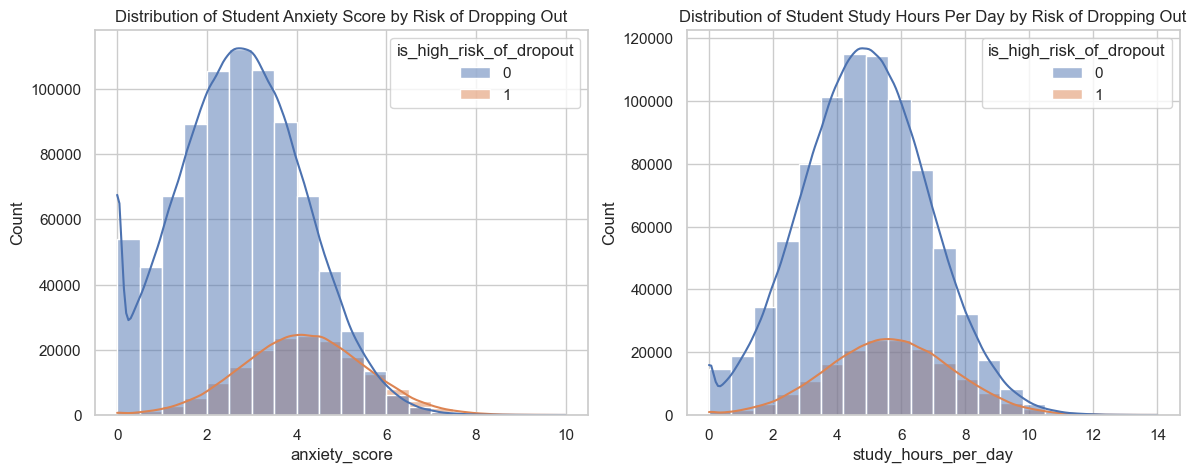

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='anxiety_score', hue='is_high_risk_of_dropout',bins=20, kde=True, color='salmon', ax=axes[0])
axes[0].set_title('Distribution of Student Anxiety Score by Risk of Dropping Out')
axes[0].ticklabel_format(style='plain')

sns.histplot(data=df, x='study_hours_per_day', hue='is_high_risk_of_dropout',bins=20, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribution of Student Study Hours Per Day by Risk of Dropping Out')
axes[1].ticklabel_format(style='plain')

plt.show()

In [117]:
X = df[['study_hours_per_day','academic_performance', 'sleep_hours','social_support','physical_activity','anxiety_score','depression_score','financial_stress','family_expectation','screen_time']]
y = df['is_high_risk_of_dropout']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_predictions = log_model.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, log_predictions)
print(f"Logistic Regression Accuracy: {log_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 87.87%


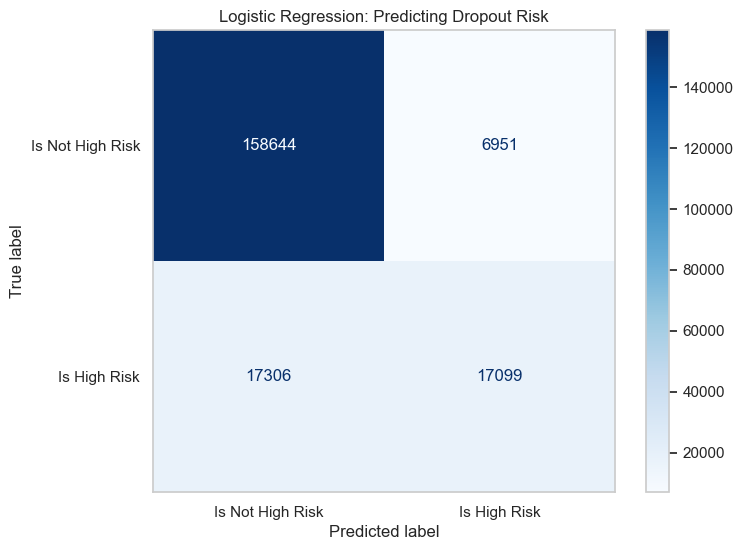

In [119]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, log_predictions)

# Plot it using the built-in Scikit-Learn display tool
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Is Not High Risk', 'Is High Risk'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Logistic Regression: Predicting Dropout Risk')
plt.grid(False) # Turn off the grid for a cleaner matrix
plt.show()

In [129]:
df['is_high_risk_of_dropout'].value_counts()
print(total_students)
dropout_risk_binary_count = df['is_high_risk_of_dropout'].value_counts()
NHR_total = dropout_risk_binary_count.max()
accuracy_guessing_NHR_all = (NHR_total / total_students) * 100
print(f"The accuracy for the logistic regression to beat: {accuracy_guessing_NHR_all:.2f}%")

1000000
The accuracy for the logistic regression to beat: 82.90%


We discussed in class how if there are way more people in the data who don't drink often compared to those who do drink often then, then if the model predicts 0 most of the time it will be right most of the time even if it does not actually learn anything from the data/predictors. However, in our case the Logistic Regression Accuracy for the model is 87.87% while the accuarcy for guessing that every student is not high risk is 82.90%. This demonstrates that the Logistic Regression Model has actually learnt some meaningful patterns that allow its accuracy to be greater than guessing the majority by 4.97%. With 1 million students in total, that represents identifying 49,700 students more accurately who would have been missed.   

Neural Network

In [121]:
nn_model = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=42)

# 3. Train the model on the SCALED data
nn_model.fit(X_train_scaled, y_train)

# 4. Make predictions
nn_predictions = nn_model.predict(X_test_scaled)

# Calculate the accuracy
nn_accuracy = accuracy_score(y_test, nn_predictions)
print(f"Neural Network Accuracy: {nn_accuracy * 100:.2f}%")
print(f"Logistic Regression Accuracy (for comparison): {log_accuracy * 100:.2f}%")

Neural Network Accuracy: 87.85%
Logistic Regression Accuracy (for comparison): 87.87%


The Neural Network Accuracy of 87.85% is actually lower than our Logistic Regression Accuracy, which is surprising because we assumed the Neural Network would perform better since they perform better on complex and non-linear relationships compared to Logistic Regression and since this data is based on human data we assume it to be complex and non-linear.   